In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from google.colab import drive

drive.mount('/content/drive')
print("Google Drive mounted successfully!")

try:
    df = pd.read_csv('/content/drive/My Drive/FAA_Dataset.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: The file was not found.")

Mounted at /content/drive
Google Drive mounted successfully!


/tmp/ipython-input-3634252157.py:10: DtypeWarning: Columns (8,9,16,19,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/FAA_Dataset.csv')


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,ENROUTE_STATE,NR_INJURIES,NR_FATALITIES,COMMENTS,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608242,1996-06-22,6,1996,NaN,NaN,KSMF,SACRAMENTO INTL,38.69542,-121.59077,...,NaN,NaN,NaN,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
1,608243,1996-06-26,6,1996,NaN,NaN,KDEN,DENVER INTL AIRPORT,39.85841,-104.667,...,NaN,NaN,NaN,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
2,608244,1996-07-01,7,1996,NaN,NaN,KOMA,EPPLEY AIRFIELD,41.30252,-95.89417,...,NaN,NaN,NaN,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
3,608245,1996-07-01,7,1996,NaN,NaN,KIAD,WASHINGTON DULLES INTL ARPT,38.94453,-77.45581,...,NaN,NaN,NaN,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
4,608246,1996-07-01,7,1996,NaN,NaN,KLGA,LA GUARDIA ARPT,40.77724,-73.87261,...,NaN,NaN,NaN,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0


In [3]:
missing_percentages = df.isnull().mean() * 100

columns_to_drop = missing_percentages[missing_percentages > 60].index

df_cleaned = df.drop(columns=columns_to_drop)

print(f"Original number of columns: {df.shape[1]}")
print(f"Number of columns dropped: {len(columns_to_drop)}")
print(f"Number of columns after dropping: {df_cleaned.shape[1]}")

display(df_cleaned.head())

Original number of columns: 100
Number of columns dropped: 17
Number of columns after dropping: 83


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,WARNED,NUM_STRUCK,SIZE,COMMENTS,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608242,1996-06-22,6,1996,NaN,NaN,KSMF,SACRAMENTO INTL,38.69542,-121.59077,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
1,608243,1996-06-26,6,1996,NaN,NaN,KDEN,DENVER INTL AIRPORT,39.85841,-104.667,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
2,608244,1996-07-01,7,1996,NaN,NaN,KOMA,EPPLEY AIRFIELD,41.30252,-95.89417,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
3,608245,1996-07-01,7,1996,NaN,NaN,KIAD,WASHINGTON DULLES INTL ARPT,38.94453,-77.45581,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
4,608246,1996-07-01,7,1996,NaN,NaN,KLGA,LA GUARDIA ARPT,40.77724,-73.87261,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0


In [4]:
df_filtered_year = df_cleaned[df_cleaned['INCIDENT_YEAR'] >= 2000].copy()

print(f"Original number of rows: {df_cleaned.shape[0]}")
print(f"Number of rows after filtering: {df_filtered_year.shape[0]}")

display(df_filtered_year.head())

Original number of rows: 330574
Number of rows after filtering: 299611


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,WARNED,NUM_STRUCK,SIZE,COMMENTS,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,Unknown,1,Small,TWO XXXX-X (XXXX-X-XX-XXXXXX & X-X-XXXXXX) /Le...,REDACTED,REDACTED,FAA Form 5200-7-E,Pilot,2007-08-21,0
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,No,1,Small,OPER RFC DALLAS INC /Legacy Record XXXXXX/,REDACTED,REDACTED,FAA Form 5200-7,Pilot,2000-10-06,0
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,No,2-10,Small,DATE POSTMARK /Legacy Record XXXXXX/,REDACTED,REDACTED,FAA Form 5200-7,NaN,2000-05-17,0
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,Unknown,1,Medium,/Legacy Record XXXXXX/,REDACTED,REDACTED,PACIR,Tower,2000-07-14,0
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,No,1,Medium,OPER BOMBARDIER AEROSPACE (BUSINESS JET SOLU...,REDACTED,REDACTED,FAA Form 5200-7,Airport Operations,2004-12-07,0


In [5]:
columns_to_drop = ['COMMENTS', 'REPORTED_NAME', 'REPORTED_TITLE', 'SOURCE', 'PERSON', 'LUPDATE', 'TRANSFER']

df_filtered_year = df_filtered_year.drop(columns=columns_to_drop)

print("Columns dropped:")
print(columns_to_drop)
print(f"Number of columns dropped: {len(columns_to_drop)}")
print(f"Number of columns after dropping: {df_filtered_year.shape[1]}")

display(df_filtered_year.head())

Columns dropped:
['COMMENTS', 'REPORTED_NAME', 'REPORTED_TITLE', 'SOURCE', 'PERSON', 'LUPDATE', 'TRANSFER']
Number of columns dropped: 7
Number of columns after dropping: 76


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,DAM_OTHER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_STRUCK,SIZE
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,0,ZT001,Eastern meadowlark,0,PILOT REPTD BIRD AS GULL. PILOT ADVISED OF POS...,1,0,Unknown,1,Small
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,0,UNKBS,Unknown bird - small,0,"DENTED LE OF RT WING ROOT. ABOUT 3-4"" DEEP. DA...",0,0,No,1,Small
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,0,UNKBS,Unknown bird - small,0,"HIT A FLOCK, ASSUME 2-10. NO DMG.",0,0,No,2-10,Small
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,0,UNKBM,Unknown bird - medium,0,"FLT 2732, PDX-SEA, HIT A BIRD.",0,0,Unknown,1,Medium
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,1,NE1,Gulls,0,"BOTH ENGS HAD INGESTION, PITOT TUBE & RT WING ...",0,0,No,1,Medium


In [6]:
df_no_duplicates = df_filtered_year.drop_duplicates()

print(f"Original number of rows: {df_filtered_year.shape[0]}")
print(f"Number of rows after dropping duplicates: {df_no_duplicates.shape[0]}")

display(df_no_duplicates.head())

Original number of rows: 299611
Number of rows after dropping duplicates: 299611


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,DAM_OTHER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_STRUCK,SIZE
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,0,ZT001,Eastern meadowlark,0,PILOT REPTD BIRD AS GULL. PILOT ADVISED OF POS...,1,0,Unknown,1,Small
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,0,UNKBS,Unknown bird - small,0,"DENTED LE OF RT WING ROOT. ABOUT 3-4"" DEEP. DA...",0,0,No,1,Small
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,0,UNKBS,Unknown bird - small,0,"HIT A FLOCK, ASSUME 2-10. NO DMG.",0,0,No,2-10,Small
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,0,UNKBM,Unknown bird - medium,0,"FLT 2732, PDX-SEA, HIT A BIRD.",0,0,Unknown,1,Medium
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,1,NE1,Gulls,0,"BOTH ENGS HAD INGESTION, PITOT TUBE & RT WING ...",0,0,No,1,Medium


In [7]:
date_column = None
if 'INCIDENT_DATE' in df_no_duplicates.columns:
    date_column = 'INCIDENT_DATE'

if date_column:

    df_no_duplicates[date_column] = pd.to_datetime(df_no_duplicates[date_column], errors='coerce')

    df_no_duplicates['incident_year'] = df_no_duplicates[date_column].dt.year
    df_no_duplicates['incident_month'] = df_no_duplicates[date_column].dt.month
    df_no_duplicates['yearmonth'] = df_no_duplicates[date_column].dt.to_period('M')
    df_no_duplicates['season'] = (df_no_duplicates[date_column].dt.month % 12 + 3) // 3
    df_no_duplicates['week_of_year'] = df_no_duplicates[date_column].dt.isocalendar().week.astype(int)
    df_no_duplicates['is_weekend'] = (df_no_duplicates[date_column].dt.dayofweek >= 5).astype(int)

    print("Derived time-based features:")
    columns_to_display = [date_column, 'incident_year', 'incident_month', 'yearmonth', 'season', 'week_of_year', 'is_weekend']

    display(df_no_duplicates[columns_to_display].head())

else:
    print("No suitable date column found.")

Derived time-based features:


,INCIDENT_DATE,incident_year,incident_month,yearmonth,season,week_of_year,is_weekend
25116,2007-05-27,2007,5,2007-05,2,21,1
25117,2000-08-06,2000,8,2000-08,3,31,1
25118,2000-03-15,2000,3,2000-03,2,11,0
25119,2000-05-08,2000,5,2000-05,2,19,0
25120,2000-03-24,2000,3,2000-03,2,12,0


In [8]:
struck_columns = [col for col in df_no_duplicates.columns if col.startswith("STR_")]
damaged_columns = [col for col in df_no_duplicates.columns if col.startswith("DAM_")]

df_no_duplicates["NUM_STRUCK_PARTS"] = df_no_duplicates[struck_columns].fillna(0).sum(axis=1)
df_no_duplicates["NUM_DAMAGED_PARTS"] = df_no_duplicates[damaged_columns].fillna(0).sum(axis=1)

display(df_no_duplicates.head())

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,NUM_STRUCK,SIZE,incident_year,incident_month,yearmonth,season,week_of_year,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,1,Small,2007,5,2007-05,2,21,1,1,0
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,1,Small,2000,8,2000-08,3,31,1,1,1
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,2-10,Small,2000,3,2000-03,2,11,0,0,0
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,1,Medium,2000,5,2000-05,2,19,0,0,0
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,1,Medium,2000,3,2000-03,2,12,0,6,4


In [9]:
engine_damage_cols = ["DAM_ENG1", "DAM_ENG2", "DAM_ENG3", "DAM_ENG4"]

df_no_duplicates["NUM_ENGINES_DAMAGED"] = df_no_duplicates[engine_damage_cols].fillna(0).sum(axis=1)
display(df_no_duplicates.head())

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,SIZE,incident_year,incident_month,yearmonth,season,week_of_year,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,Small,2007,5,2007-05,2,21,1,1,0,0
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,Small,2000,8,2000-08,3,31,1,1,1,0
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,Small,2000,3,2000-03,2,11,0,0,0,0
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,Medium,2000,5,2000-05,2,19,0,0,0,0
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,Medium,2000,3,2000-03,2,12,0,6,4,2


In [10]:
any_damage_columns = [col for col in df_no_duplicates.columns if col.startswith("DAM_")]

df_no_duplicates["ANY_DAMAGE"] = (df_no_duplicates[any_damage_columns].fillna(0).sum(axis=1) > 0).astype(int)
display(df_no_duplicates.head())

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,incident_year,incident_month,yearmonth,season,week_of_year,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED,ANY_DAMAGE
25116,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,2007,5,2007-05,2,21,1,1,0,0,0
25117,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,2000,8,2000-08,3,31,1,1,1,0,1
25118,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,2000,3,2000-03,2,11,0,0,0,0,0
25119,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,2000,5,2000-05,2,19,0,0,0,0,0
25120,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,2000,3,2000-03,2,12,0,6,4,2,1


In [11]:
threshold = 0.20
row_missing_fraction = df_no_duplicates.isnull().mean(axis=1)

to_drop_mask = row_missing_fraction > threshold

n_total = len(df_no_duplicates)
n_drop = to_drop_mask.sum()
print(f"Rows to drop: {n_drop} / {n_total}  ({n_drop/n_total:.1%})")

df_no_duplicates = df_no_duplicates[~to_drop_mask].reset_index(drop=True)

print("Dataframe shape after drop:", df_no_duplicates.shape)


Rows to drop: 56703 / 299611  (18.9%)
Dataframe shape after drop: (242908, 86)


In [12]:
display(df_no_duplicates.head())

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,incident_year,incident_month,yearmonth,season,week_of_year,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED,ANY_DAMAGE
0,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,2007,5,2007-05,2,21,1,1,0,0,0
1,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,2000,8,2000-08,3,31,1,1,1,0,1
2,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,2000,3,2000-03,2,11,0,0,0,0,0
3,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,2000,5,2000-05,2,19,0,0,0,0,0
4,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,2000,3,2000-03,2,12,0,6,4,2,1


In [13]:

df_no_duplicates["HEIGHT_BUCKET"] = pd.cut(
    df_no_duplicates["HEIGHT"],
    bins=[-np.inf, 100, 1000, 5000, 10000, np.inf],
    labels=["Ground", "Low height", "Medium height", "High height", "Very_High"]
)

df_no_duplicates["FLIGHT_PHASE_BUCKET"] = (
    df_no_duplicates["PHASE_OF_FLIGHT"].astype(str) + "_" + df_no_duplicates["HEIGHT_BUCKET"].astype(str)
)
display(df_no_duplicates.head())

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,yearmonth,season,week_of_year,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED,ANY_DAMAGE,HEIGHT_BUCKET,FLIGHT_PHASE_BUCKET
0,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,2007-05,2,21,1,1,0,0,0,Ground,Take-off Run_Ground
1,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,2000-08,3,31,1,1,1,0,1,Medium height,En Route_Medium height
2,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,2000-03,2,11,0,0,0,0,0,Low height,Approach_Low height
3,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,2000-05,2,19,0,0,0,0,0,Ground,Take-off Run_Ground
4,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,2000-03,2,12,0,6,4,2,1,Medium height,En Route_Medium height


In [14]:
phase_weights = {
    "TAXI": 0,
    "PARKED": 0,
    "TAKEOFF": 3,
    "CLIMB": 3,
    "APPROACH": 3,
    "LANDING": 3,
    "EN ROUTE": 2,
    "CRUISE": 2,
    "DESCENT": 2,
    "OTHER": 1,
    "UNKNOWN": 1
}

df_no_duplicates["PHASE_WEIGHT"] = (
    df_no_duplicates["PHASE_OF_FLIGHT"]
    .str.upper()
    .map(phase_weights)
    .fillna(1)
)

height_weight_map = {
    "Ground": 2,
    "Low height": 2,
    "Medium height": 1,
    "High height": 1,
    "Very_High": 0
}

df_no_duplicates["HEIGHT_WEIGHT"] = df_no_duplicates["HEIGHT_BUCKET"].map(height_weight_map)
df_no_duplicates["DAMAGE_SEVERITY_SCORE"] = (
    (df_no_duplicates["NUM_STRUCK_PARTS"] * 1) +
    (df_no_duplicates["NUM_DAMAGED_PARTS"] * 2) +
    (df_no_duplicates["NUM_ENGINES_DAMAGED"] * 3) +
    (df_no_duplicates["HEIGHT_WEIGHT"].fillna(0)) +
    (df_no_duplicates["PHASE_WEIGHT"].fillna(0))
)

display(df_no_duplicates.head())


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,is_weekend,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED,ANY_DAMAGE,HEIGHT_BUCKET,FLIGHT_PHASE_BUCKET,PHASE_WEIGHT,HEIGHT_WEIGHT,DAMAGE_SEVERITY_SCORE
0,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,1,1,0,0,0,Ground,Take-off Run_Ground,1.0,2.0,4.0
1,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,1,1,1,0,1,Medium height,En Route_Medium height,2.0,1.0,6.0
2,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,0,0,0,0,0,Low height,Approach_Low height,3.0,2.0,5.0
3,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,0,0,0,0,0,Ground,Take-off Run_Ground,1.0,2.0,3.0
4,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,0,6,4,2,1,Medium height,En Route_Medium height,2.0,1.0,23.0


In [15]:
df_no_duplicates["SEVERITY_LEVEL"] = pd.cut(
    df_no_duplicates["DAMAGE_SEVERITY_SCORE"],
    bins=[-np.inf, 3, 7, 12, np.inf],
    labels=["Minor", "Moderate", "Major", "Severe"]
)
display(df_no_duplicates.head())


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,NUM_STRUCK_PARTS,NUM_DAMAGED_PARTS,NUM_ENGINES_DAMAGED,ANY_DAMAGE,HEIGHT_BUCKET,FLIGHT_PHASE_BUCKET,PHASE_WEIGHT,HEIGHT_WEIGHT,DAMAGE_SEVERITY_SCORE,SEVERITY_LEVEL
0,638332,2007-05-27,5,2007,08:35,Day,KHOU,WILLIAM P HOBBY ARPT,29.64542,-95.27889,...,1,0,0,0,Ground,Take-off Run_Ground,1.0,2.0,4.0,Moderate
1,638334,2000-08-06,8,2000,NaN,Day,ZZZZ,UNKNOWN,NaN,NaN,...,1,1,0,1,Medium height,En Route_Medium height,2.0,1.0,6.0,Moderate
2,638335,2000-03-15,3,2000,NaN,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,0,0,0,0,Low height,Approach_Low height,3.0,2.0,5.0,Moderate
3,638336,2000-05-08,5,2000,11:25,Day,KPDX,PORTLAND INTL (OR),45.58872,-122.5975,...,0,0,0,0,Ground,Take-off Run_Ground,1.0,2.0,3.0,Minor
4,638337,2000-03-24,3,2000,18:40,Dusk,ZZZZ,UNKNOWN,NaN,NaN,...,6,4,2,1,Medium height,En Route_Medium height,2.0,1.0,23.0,Severe


In [16]:
df_no_duplicates["TOTAL_PARTS_AFFECTED"] = (
    df_no_duplicates["NUM_STRUCK_PARTS"] + df_no_duplicates["NUM_DAMAGED_PARTS"]
)
df_no_duplicates["ANY_ENGINE_DAMAGE"] = (df_no_duplicates["NUM_ENGINES_DAMAGED"] > 0).astype(int)

In [17]:

df = df_no_duplicates.copy()

total_incidents = len(df)
str_cols = [c for c in df.columns if c.startswith("STR_")]
dam_cols = [c for c in df.columns if c.startswith("DAM_")]

print(f"Total incidents: {total_incidents}\n")

Total incidents: 242908



In [18]:
print("Struck rate per part:")
if str_cols:
    struck_counts = df[str_cols].fillna(0).astype(int).sum().sort_values(ascending=False)
    struck_pct = (struck_counts / total_incidents * 100).round(1)
    struck_df = pd.DataFrame({
        "part": struck_counts.index,
        "struck_count": struck_counts.values,
        "struck_%_of_all_incidents": struck_pct.values
    }).reset_index(drop=True)
    print(struck_df.head(15).to_string(index=False))

print("\n" + "-"*80 + "\n")

print("Damage rate per part:")
if dam_cols:
    damage_counts = df[dam_cols].fillna(0).astype(int).sum().sort_values(ascending=False)
    damage_pct = (damage_counts / total_incidents * 100).round(1)
    damage_df = pd.DataFrame({
        "part": damage_counts.index,
        "damage_count": damage_counts.values,
        "damage_pct_of_all_incidents": damage_pct.values
    }).reset_index(drop=True)
    print(damage_df.head(15).to_string(index=False))

print("\n" + "-"*80 + "\n")


Struck rate per part:
        part  struck_count  struck_%_of_all_incidents
   STR_OTHER         43352                       17.8
STR_WING_ROT         36576                       15.1
    STR_NOSE         34647                       14.3
STR_WINDSHLD         34518                       14.2
     STR_RAD         26407                       10.9
    STR_FUSE         25760                       10.6
    STR_ENG1         12698                        5.2
      STR_LG         12307                        5.1
    STR_ENG2         11205                        4.6
    STR_PROP          4231                        1.7
    STR_TAIL          2912                        1.2
   STR_LGHTS          1324                        0.5
    STR_ENG3           319                        0.1
    STR_ENG4           147                        0.1

--------------------------------------------------------------------------------

Damage rate per part:
        part  damage_count  damage_pct_of_all_incidents
DAM_WIN

/tmp/ipython-input-3259102521.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='part', y='struck_%_of_all_incidents', data=struck_df.head(15), palette='viridis')


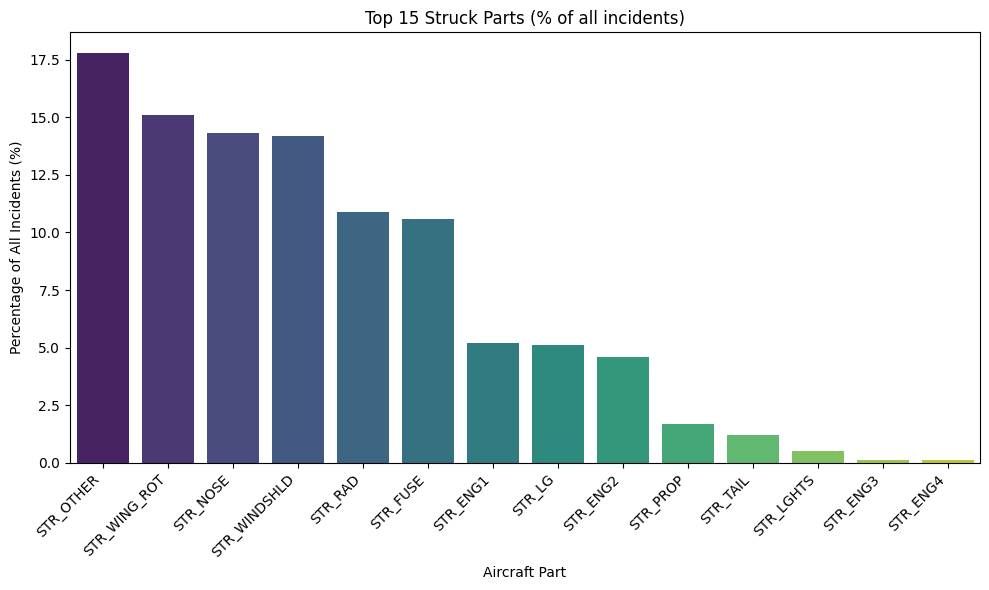

/tmp/ipython-input-3259102521.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='part', y='damage_pct_of_all_incidents', data=damage_df.head(15), palette='magma')


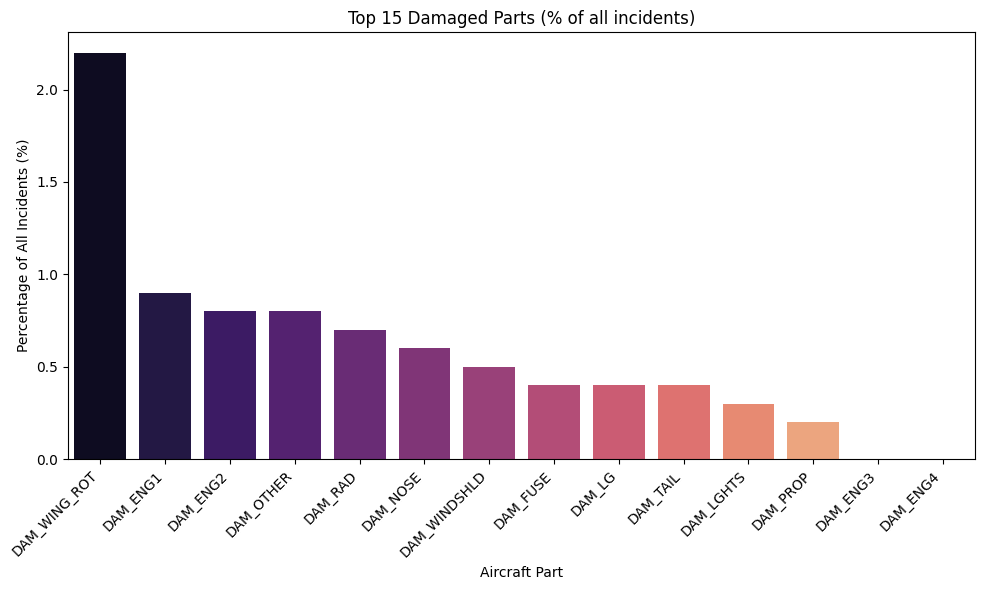

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'struck_df' in globals() and not struck_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='part', y='struck_%_of_all_incidents', data=struck_df.head(15), palette='viridis')
    plt.title('Top 15 Struck Parts (% of all incidents)')
    plt.xlabel('Aircraft Part')
    plt.ylabel('Percentage of All Incidents (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Struck rate data not available for plotting.")

if 'damage_df' in globals() and not damage_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='part', y='damage_pct_of_all_incidents', data=damage_df.head(15), palette='magma')
    plt.title('Top 15 Damaged Parts (% of all incidents)')
    plt.xlabel('Aircraft Part')
    plt.ylabel('Percentage of All Incidents (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Damage rate data not available for plotting.")

In [20]:
print("Total number per severity level:")
severity_counts = df["SEVERITY_LEVEL"].value_counts(dropna=False).rename_axis("severity").reset_index(name="count")
print(severity_counts.to_string(index=False))

print("\n" + "-"*80 + "\n")

print("Strikes number per season:")
season_counts = df["season"].fillna("UNKNOWN").value_counts().rename_axis("season").reset_index(name="count")
print(season_counts.to_string(index=False))

print("\n" + "-"*80 + "\n")

print("Strikes distribution over years:")
year_counts = df["INCIDENT_YEAR"].dropna().astype(int).value_counts().sort_index().rename_axis("year").reset_index(name="count")
print(year_counts.to_string(index=False))

print("\n" + "-"*80 + "\n")


Total number per severity level:
severity  count
Moderate 156982
   Minor  75080
   Major   9799
  Severe   1047

--------------------------------------------------------------------------------

Strikes number per season:
 season  count
      3  83507
      4  79478
      2  56294
      1  23629

--------------------------------------------------------------------------------

Strikes distribution over years:
 year  count
 2000   5245
 2001   4924
 2002   5232
 2003   4996
 2004   5448
 2005   5866
 2006   5656
 2007   5708
 2008   5293
 2009   7033
 2010   6923
 2011   6958
 2012   7489
 2013   7603
 2014   9589
 2015   9535
 2016  10028
 2017   9892
 2018  11114
 2019  15257
 2020  10636
 2021  14647
 2022  16303
 2023  18810
 2024  21632
 2025  11091

--------------------------------------------------------------------------------



/tmp/ipython-input-1236794673.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='severity', y='count', data=severity_counts, palette='viridis')


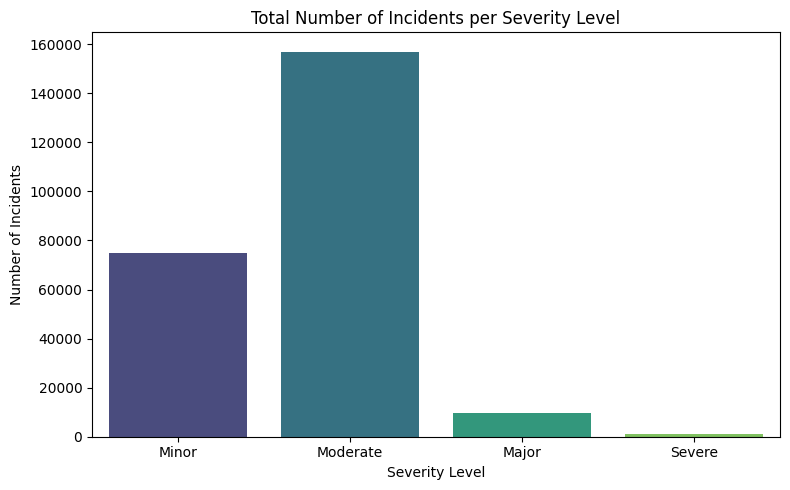

/tmp/ipython-input-1236794673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='count', data=season_counts.sort_values('season'), palette='magma')


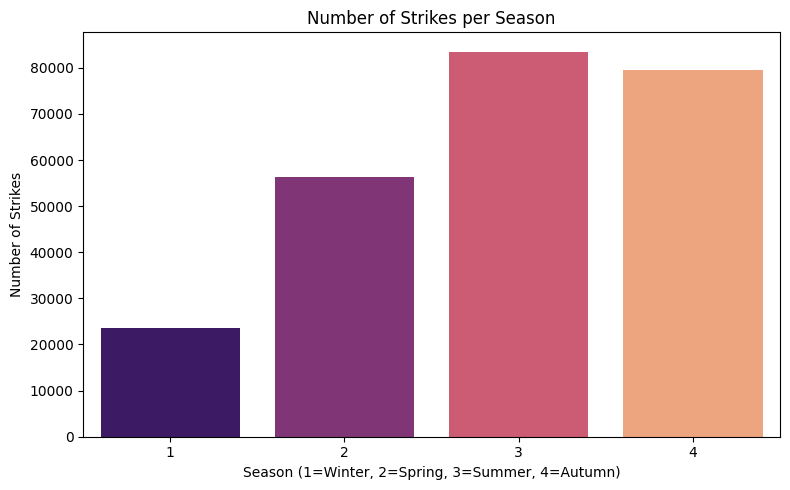

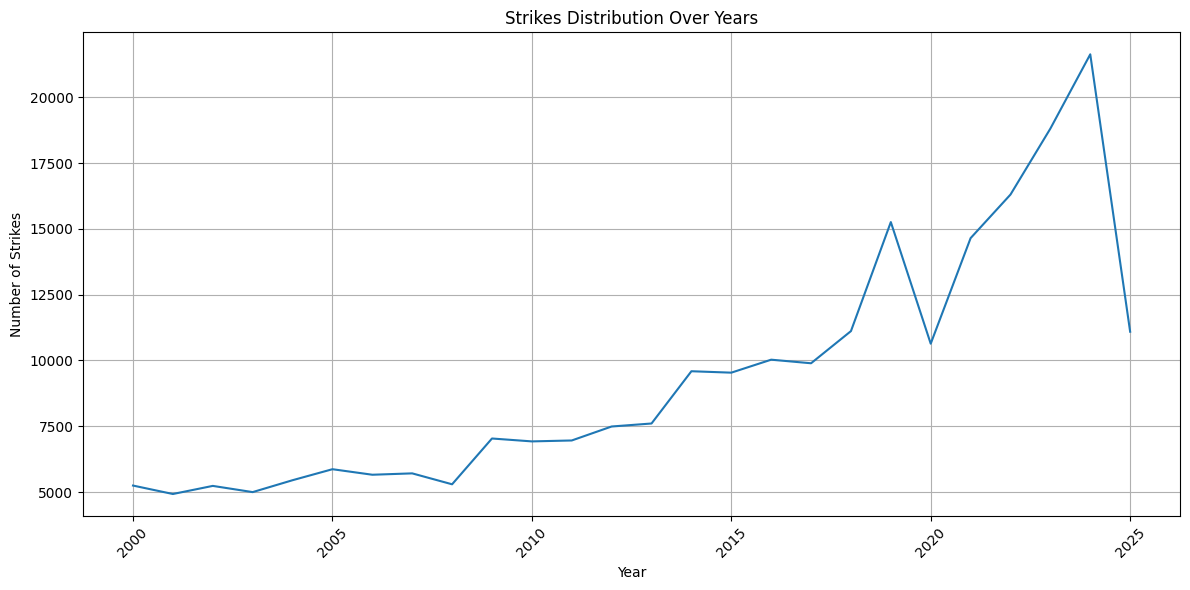

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'severity_counts' in globals() and not severity_counts.empty:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='severity', y='count', data=severity_counts, palette='viridis')
    plt.title('Total Number of Incidents per Severity Level')
    plt.xlabel('Severity Level')
    plt.ylabel('Number of Incidents')
    plt.tight_layout()
    plt.show()
else:
    print("Severity level data not available for plotting.")

if 'season_counts' in globals() and not season_counts.empty:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='season', y='count', data=season_counts.sort_values('season'), palette='magma')
    plt.title('Number of Strikes per Season')
    plt.xlabel('Season (1=Winter, 2=Spring, 3=Summer, 4=Autumn)')
    plt.ylabel('Number of Strikes')
    plt.tight_layout()
    plt.show()
else:
    print("Season data not available for plotting.")

if 'year_counts' in globals() and not year_counts.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='year', y='count', data=year_counts)
    plt.title('Strikes Distribution Over Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Strikes')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Year distribution data not available for plotting.")

In [22]:
print("Any damage rate across all strikes:")
any_damage_rate = df["ANY_DAMAGE"].fillna(0).astype(int).sum() / total_incidents
print(f"Any damage rate : {any_damage_rate:.3%}")

print("\n" + "-"*80 + "\n")

print("Any engine damage rate across all strikes:")
any_engine_damage_rate = (df["NUM_ENGINES_DAMAGED"].fillna(0).astype(int) > 0).sum() / total_incidents
print(f" Any engine damage rate: {any_engine_damage_rate:.3%}")

print("\n" + "-"*80 + "\n")

print("Top 10 aircrafts struck:")
top_aircraft = df["AIRCRAFT"].fillna("UNKNOWN").value_counts().head(10).rename_axis("AIRCRAFT").reset_index(name="count")
print(top_aircraft.to_string(index=False))

print("\n" + "-"*80 + "\n")



Any damage rate across all strikes:
Any damage rate : 6.751%

--------------------------------------------------------------------------------

Any engine damage rate across all strikes:
 Any engine damage rate: 1.652%

--------------------------------------------------------------------------------

Top 10 aircrafts struck:
  AIRCRAFT  count
   UNKNOWN  33665
     A-320  15872
 B-737-800  13343
 B-737-700  11863
   EMB-170  10925
     A-319   9754
CRJ100/200   9583
     A-321   7747
 B-757-200   7495
 B-737-300   7045

--------------------------------------------------------------------------------



In [23]:


print("Top 10 states by number of strikes:")
top_states = df["STATE"].fillna("UNKNOWN").value_counts().head(10).rename_axis("STATE").reset_index(name="count")
print(top_states.to_string(index=False))

print("\n" + "-"*80 + "\n")


Top 10 states by number of strikes:
  STATE  count
UNKNOWN  40285
     TX  21258
     FL  17970
     CA  17386
     CO   9956
     NY   9452
     IL   8599
     TN   8373
     PA   6140
     KY   5840

--------------------------------------------------------------------------------



In [24]:
print("Number of strikes per flight phase:")
phase_counts = (
    df["PHASE_OF_FLIGHT"]
    .value_counts(dropna=False)
    .rename_axis("flight_phase")
    .reset_index(name="count")
)
phase_counts["percentage"] = (phase_counts["count"] / total_incidents * 100).round(2)
print(phase_counts.to_string(index=False))

print("\n" + "-"*80 + "\n")

print("Number of strikes per flight phase bucket:")
F_phase_counts = (
    df["FLIGHT_PHASE_BUCKET"]
    .value_counts(dropna=False)
    .rename_axis("flight_phase_bucket")
    .reset_index(name="count")
)
F_phase_counts["percentage"] = (F_phase_counts["count"] / total_incidents * 100).round(2)
print(F_phase_counts.to_string(index=False))

Number of strikes per flight phase:
flight_phase  count  percentage
    Approach  75245       30.98
         NaN  67628       27.84
Landing Roll  32061       13.20
Take-off Run  28702       11.82
       Climb  25017       10.30
    En Route   5114        2.11
   Departure   3593        1.48
     Descent   2513        1.03
       Local   1356        0.56
     Arrival    902        0.37
        Taxi    668        0.28
      Parked    104        0.04
     Unknown      5        0.00

--------------------------------------------------------------------------------

Number of strikes per flight phase bucket:
    flight_phase_bucket  count  percentage
                nan_nan  67372       27.74
    Landing Roll_Ground  32061       13.20
    Take-off Run_Ground  28702       11.82
    Approach_Low height  20903        8.61
           Approach_nan  19407        7.99
 Approach_Medium height  18319        7.54
        Approach_Ground  14611        6.02
           Climb_Ground   6653        2.74
   

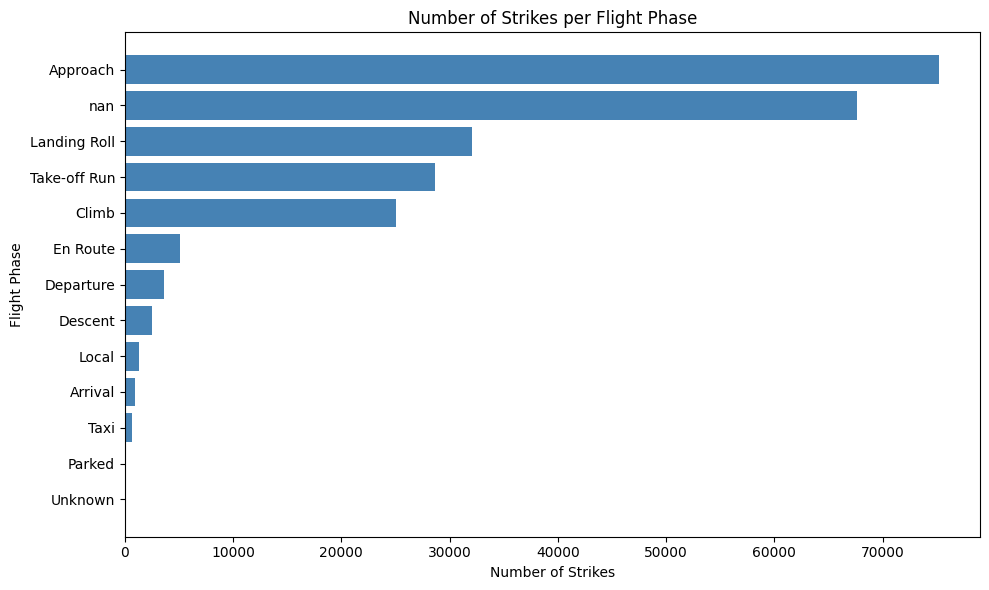

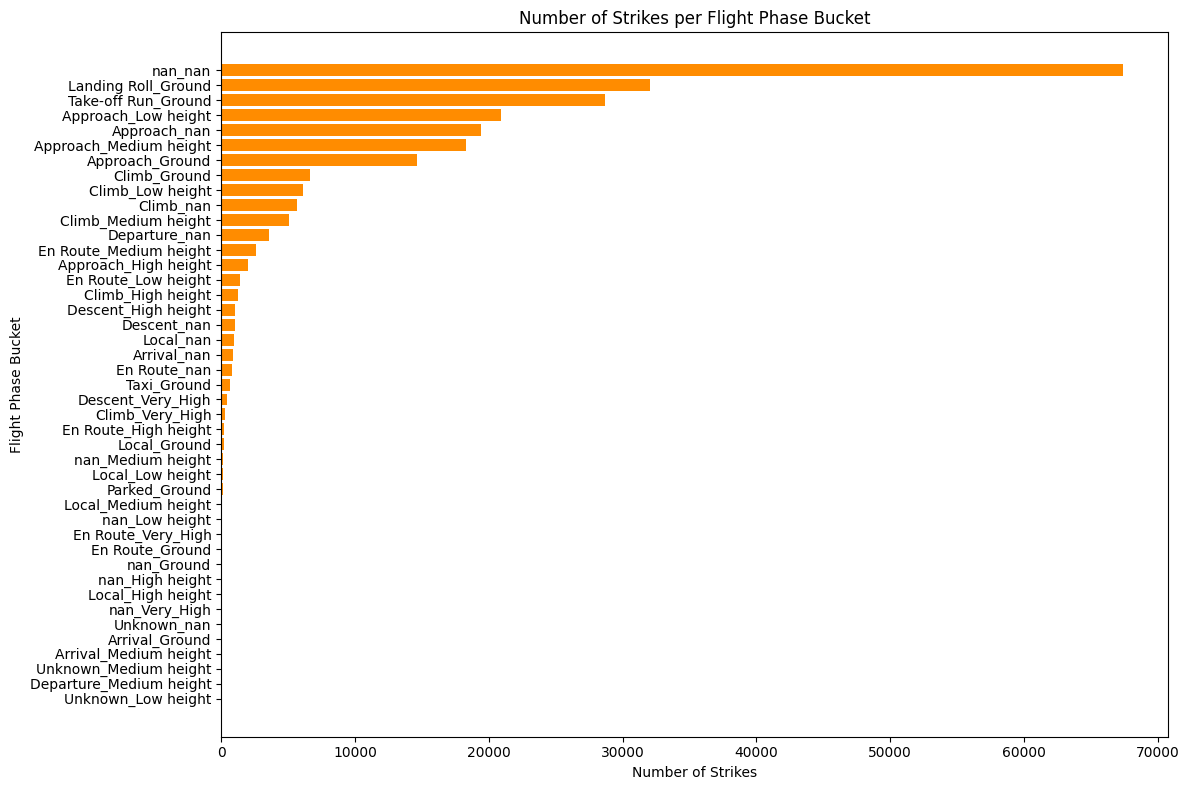

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'phase_counts' in globals() and not phase_counts.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(phase_counts["flight_phase"].astype(str), phase_counts["count"], color="steelblue")
    plt.xlabel("Number of Strikes")
    plt.ylabel("Flight Phase")
    plt.title("Number of Strikes per Flight Phase")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Flight phase data not available for plotting.")

if 'F_phase_counts' in globals() and not F_phase_counts.empty:
    plt.figure(figsize=(12, 8))
    plt.barh(F_phase_counts["flight_phase_bucket"].astype(str), F_phase_counts["count"], color="darkorange")
    plt.xlabel("Number of Strikes")
    plt.ylabel("Flight Phase Bucket")
    plt.title("Number of Strikes per Flight Phase Bucket")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Flight phase bucket data not available for plotting.")

In [26]:
print("Top 10 bird species by number of strikes:")

top_species = (
    df["SPECIES"]
    .value_counts(dropna=False)
    .rename_axis("species")
    .reset_index(name="count")
    .head(10)
)

print(top_species.to_string(index=False))

Top 10 bird species by number of strikes:
              species  count
 Unknown bird - small  46905
         Unknown bird  32335
Unknown bird - medium  29659
        Mourning dove   9869
         Barn swallow   8254
          Horned lark   6288
             Killdeer   6157
     American kestrel   5498
    European starling   4265
                Gulls   3934


In [27]:
print("Relation between Top 10 States and Severity Level:")
top_states = (
    df["STATE"]
    .value_counts()
    .head(10)
    .rename_axis("STATE")
    .reset_index(name="total_strikes")
)
state_severity = (
    df[df["STATE"].isin(top_states["STATE"])]
    .groupby(["STATE", "SEVERITY_LEVEL"])
    .size()
    .reset_index(name="count")
)

state_severity = state_severity.merge(top_states, on="STATE", how="left")
state_severity = state_severity.sort_values(["total_strikes", "STATE", "count"], ascending=[False, True, False])

print(state_severity.to_string(index=False))

Relation between Top 10 States and Severity Level:
STATE SEVERITY_LEVEL  count  total_strikes
   TX       Moderate  14948          21258
   TX          Minor   5480          21258
   TX          Major    770          21258
   TX         Severe     60          21258
   FL       Moderate  13369          17970
   FL          Minor   3479          17970
   FL          Major   1043          17970
   FL         Severe     79          17970
   CA       Moderate  13670          17386
   CA          Minor   2552          17386
   CA          Major   1043          17386
   CA         Severe    121          17386
   CO       Moderate   6041           9956
   CO          Minor   3659           9956
   CO          Major    233           9956
   CO         Severe     23           9956
   NY       Moderate   7290           9452
   NY          Minor   1617           9452
   NY          Major    494           9452
   NY         Severe     51           9452
   IL       Moderate   6051           8599
   

/tmp/ipython-input-4051963762.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["STATE", "SEVERITY_LEVEL"])


/tmp/ipython-input-1824356828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='count', data=top_species, palette='viridis')


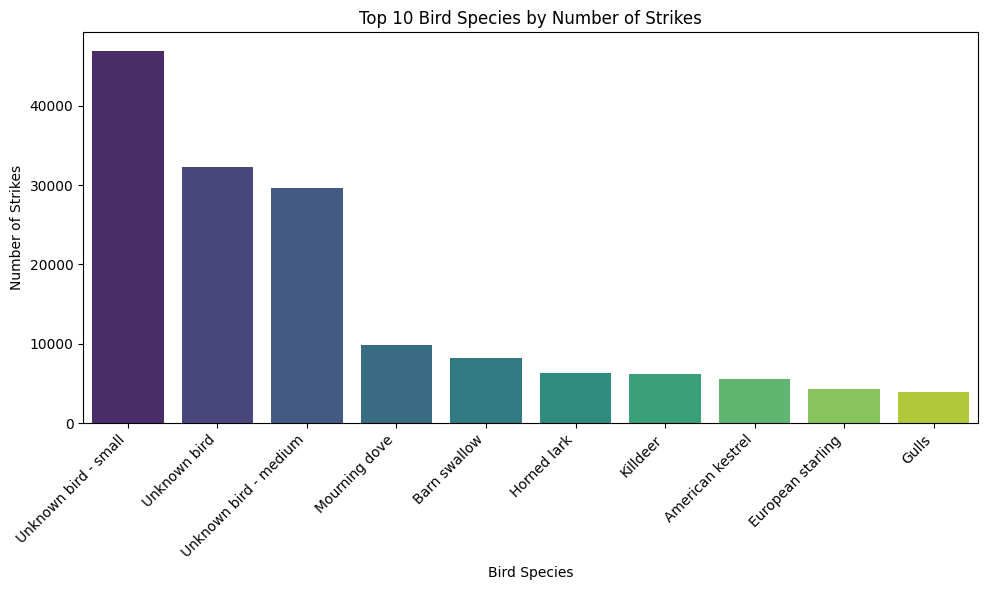

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline


if 'top_species' in globals() and not top_species.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='species', y='count', data=top_species, palette='viridis')
    plt.title('Top 10 Bird Species by Number of Strikes')
    plt.xlabel('Bird Species')
    plt.ylabel('Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top species data not available for plotting.")

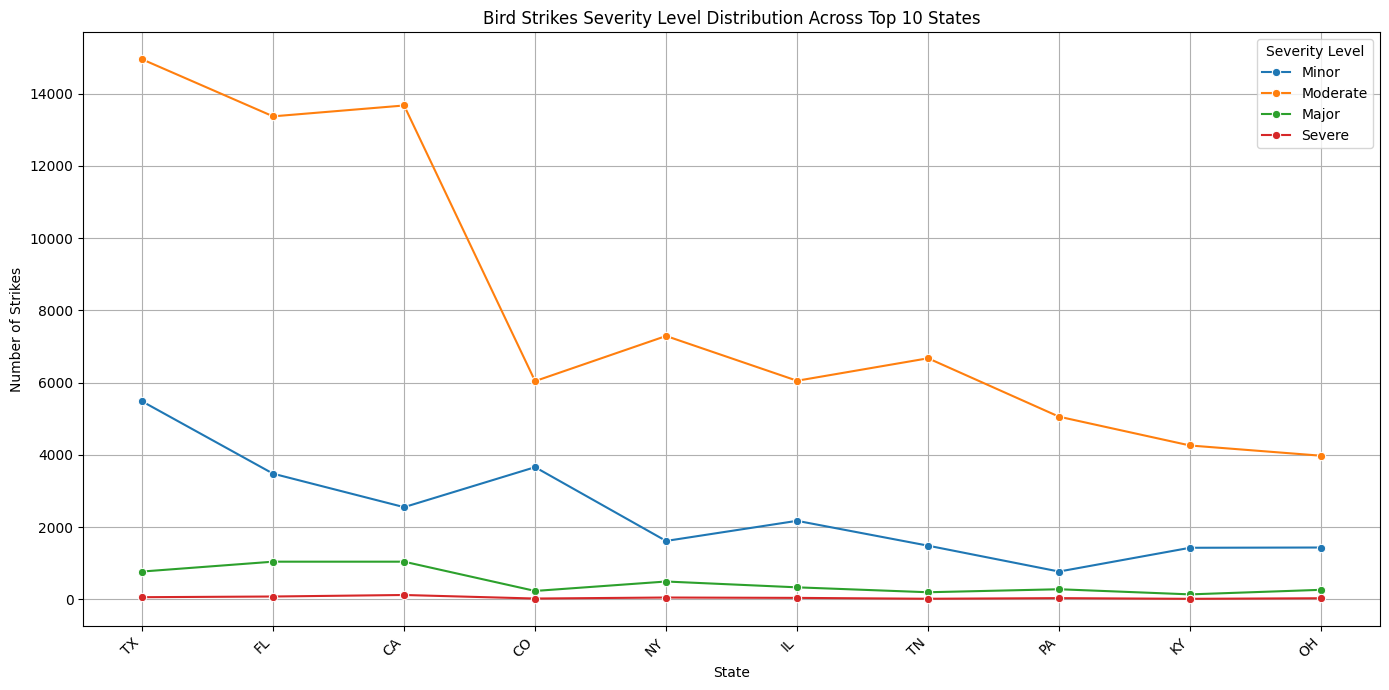

/tmp/ipython-input-2929162250.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='STATE', y='total_strikes', data=top_states, palette='viridis') # Use total_strikes from top_states


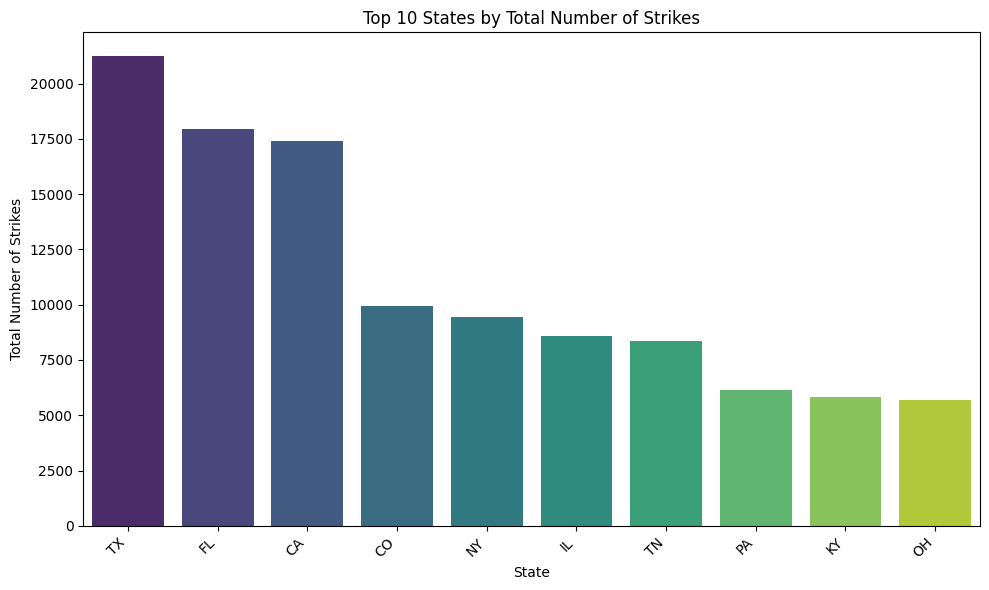

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'state_severity' in globals() and not state_severity.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='STATE', y='count', hue='SEVERITY_LEVEL', data=state_severity, marker='o')
    plt.title('Bird Strikes Severity Level Distribution Across Top 10 States')
    plt.xlabel('State')
    plt.ylabel('Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Severity Level')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("State and severity data not available for plotting.")

if 'top_states' in globals() and not top_states.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='STATE', y='total_strikes', data=top_states, palette='viridis')
    plt.title('Top 10 States by Total Number of Strikes')
    plt.xlabel('State')
    plt.ylabel('Total Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top states data not available for plotting.")

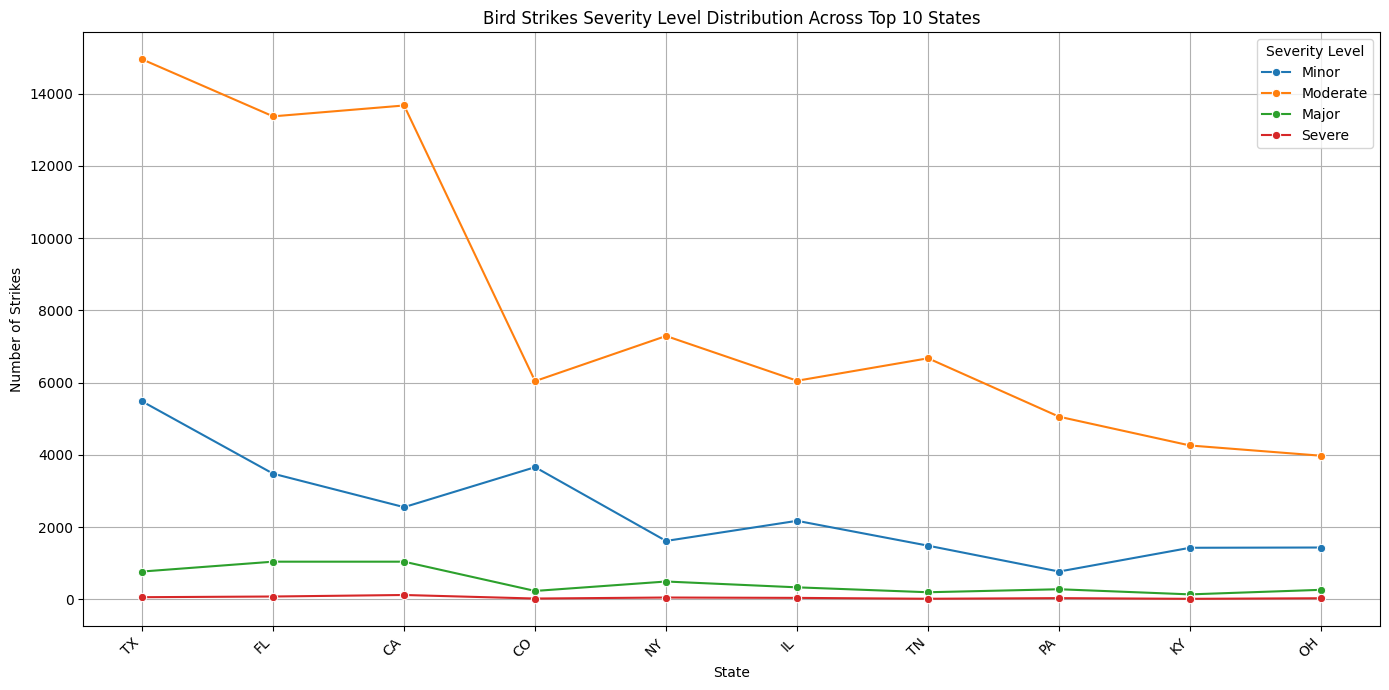

/tmp/ipython-input-3000283073.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='STATE', y='total_strikes', data=top_states, palette='viridis') # Use total_strikes from top_states


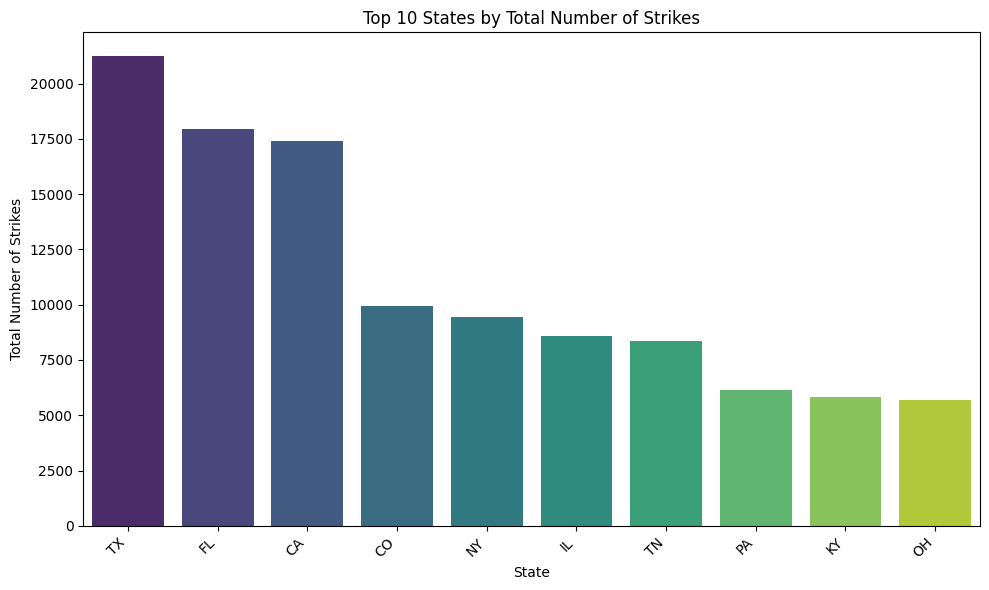

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'state_severity' in globals() and not state_severity.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='STATE', y='count', hue='SEVERITY_LEVEL', data=state_severity, marker='o')
    plt.title('Bird Strikes Severity Level Distribution Across Top 10 States')
    plt.xlabel('State')
    plt.ylabel('Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Severity Level')
    plt.grid(True) #
    plt.tight_layout()
    plt.show()
else:
    print("State and severity data not available for plotting.")

if 'top_states' in globals() and not top_states.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='STATE', y='total_strikes', data=top_states, palette='viridis')
    plt.title('Top 10 States by Total Number of Strikes')
    plt.xlabel('State')
    plt.ylabel('Total Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top states data not available for plotting.")

In [31]:
print("Strike Severity Levels Over the Years:")

severity_over_years = (
    df.groupby(["INCIDENT_YEAR", "SEVERITY_LEVEL"])
    .size()
    .reset_index(name="count")
    .sort_values(["INCIDENT_YEAR", "SEVERITY_LEVEL"], ascending=[True, True])
)

print(severity_over_years.to_string(index=False))

Strike Severity Levels Over the Years:
 INCIDENT_YEAR SEVERITY_LEVEL  count
          2000          Minor   1505
          2000       Moderate   3257
          2000          Major    434
          2000         Severe     49
          2001          Minor   1238
          2001       Moderate   3283
          2001          Major    356
          2001         Severe     47
          2002          Minor   1302
          2002       Moderate   3511
          2002          Major    372
          2002         Severe     47
          2003          Minor    912
          2003       Moderate   3642
          2003          Major    385
          2003         Severe     57
          2004          Minor    788
          2004       Moderate   4247
          2004          Major    364
          2004         Severe     49
          2005          Minor   1176
          2005       Moderate   4277
          2005          Major    368
          2005         Severe     45
          2006          Minor    873

/tmp/ipython-input-3903018951.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["INCIDENT_YEAR", "SEVERITY_LEVEL"])


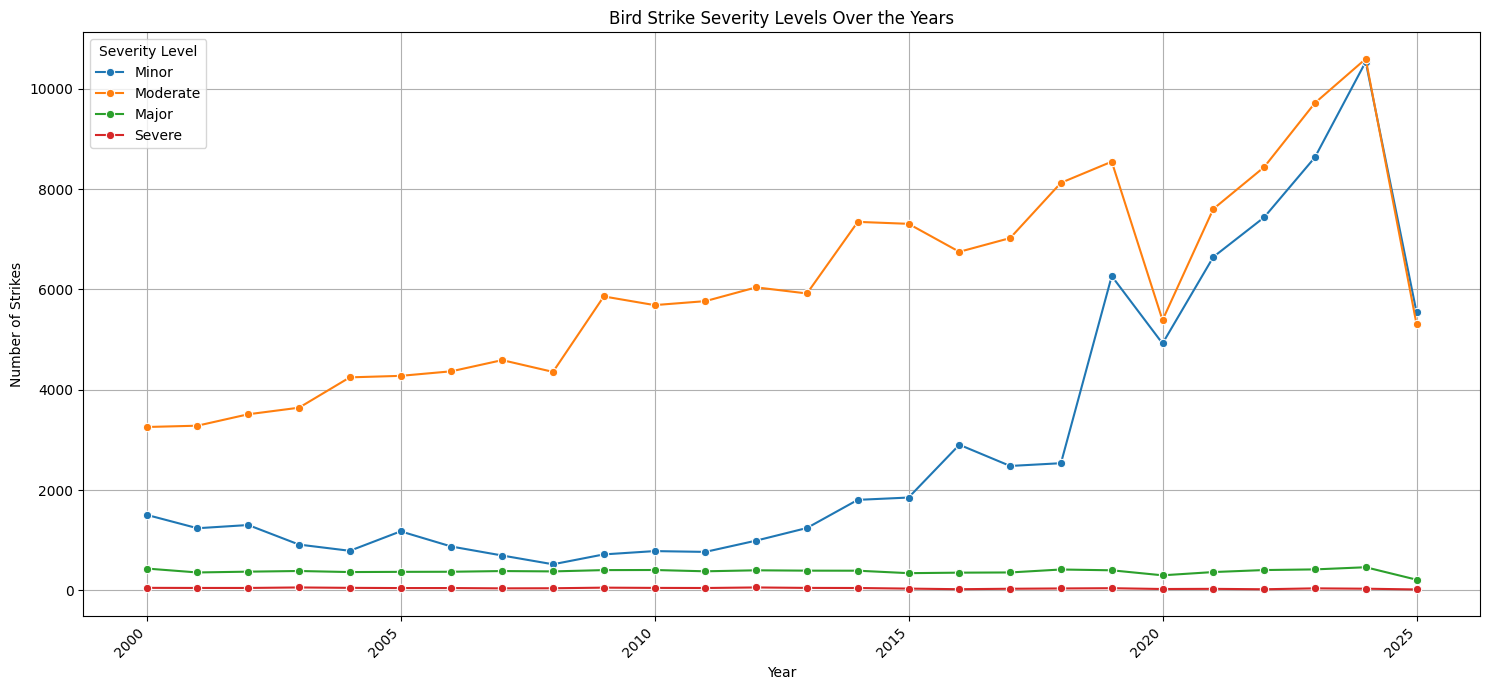

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'severity_over_years' in globals() and not severity_over_years.empty:
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='INCIDENT_YEAR', y='count', hue='SEVERITY_LEVEL', data=severity_over_years, marker='o')
    plt.title('Bird Strike Severity Levels Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Severity Level')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Severity over years data not available for plotting.")

In [33]:

import plotly.express as px
state_strikes = df["STATE"].value_counts().reset_index()
state_strikes.columns = ["STATE", "count"]

fig = px.choropleth(
    state_strikes,
    locations="STATE",
    locationmode="USA-states",
    color="count",
    color_continuous_scale="Reds",
    scope="usa",
    title="Wildlife Strikes by U.S. State",
    labels={"count": "Number of Strikes"}
)

fig.show()

In [35]:
bucket_stats = (
    df_no_duplicates["HEIGHT_BUCKET"]
    .value_counts(sort=False, normalize=False)
    .rename("count")
    .to_frame()
)

bucket_stats["percentage"] = (
    df_no_duplicates["HEIGHT_BUCKET"]
    .value_counts(sort=False, normalize=True)
    .round(2)
)

print(bucket_stats)

               count  percentage
HEIGHT_BUCKET                   
Ground         83115        0.58
Low height     28612        0.20
Medium height  26146        0.18
High height     4577        0.03
Very_High        797        0.01


In [36]:
import plotly.express as px

damage_state = df.groupby("STATE")["ANY_DAMAGE"].sum().reset_index()
damage_state.columns = ["STATE", "total_damage"]

fig = px.choropleth(
    damage_state,
    locations="STATE",
    locationmode="USA-states",
    color="total_damage",
    color_continuous_scale="Reds",
    scope="usa",
    title="Wildlife Damage by U.S. State",
    labels={"total_damage": "Total Damage Events"}
)

fig.show()


In [38]:
damage_per_season = df.groupby("season")["ANY_DAMAGE"].sum().reset_index()
print(damage_per_season.to_string(index=False))


 season  ANY_DAMAGE
      1        2745
      2        4361
      3        3660
      4        5633


In [41]:
damage_by_severity = (
    df.groupby("SEVERITY_LEVEL")["ANY_DAMAGE"]
      .sum()
      .reset_index()
)

print(damage_by_severity.to_string(index=False))

SEVERITY_LEVEL  ANY_DAMAGE
         Minor           3
      Moderate        7890
         Major        7497
        Severe        1009


/tmp/ipython-input-1448860705.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [42]:
df_damage_only = df[df["ANY_DAMAGE"] == 1]

damage_over_years = (
    df_damage_only
    .groupby(["INCIDENT_YEAR", "SEVERITY_LEVEL"])
    .size()
    .reset_index(name="count")
)

/tmp/ipython-input-1847250680.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



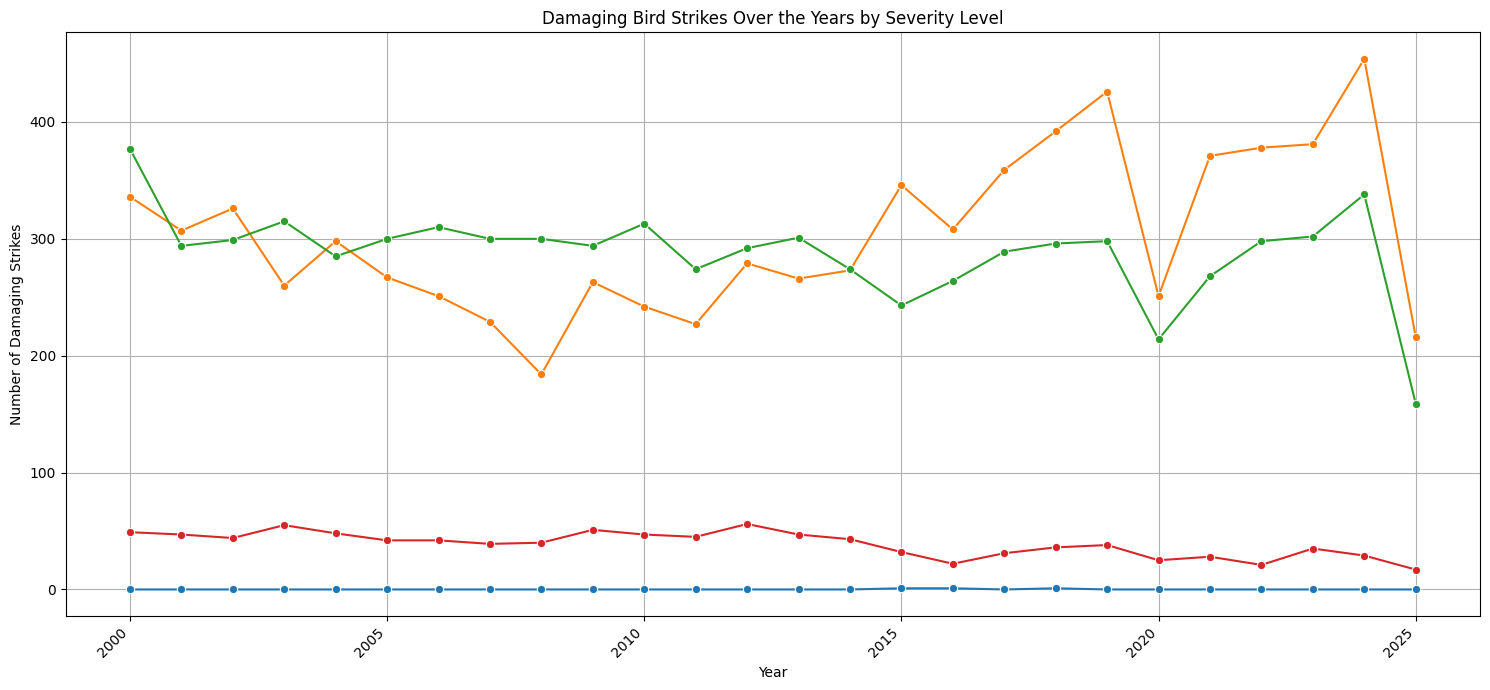

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

if 'damage_over_years' in globals() and not damage_over_years.empty:
    plt.figure(figsize=(15, 7))
    sns.lineplot(
        x='INCIDENT_YEAR',
        y='count',
        hue='SEVERITY_LEVEL',
        data=damage_over_years,
        marker='o'
    )
    plt.title('Damaging Bird Strikes Over the Years by Severity Level')
    plt.xlabel('Year')
    plt.ylabel('Number of Damaging Strikes')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
    plt.tight_layout()

    plt.legend().remove()

    plt.show()
else:
    print("Damage-over-years data not available for plotting.")


In [46]:
damage_per_height = (
    df.groupby("HEIGHT_BUCKET")["ANY_DAMAGE"]
      .sum()
      .reset_index()
)

print(damage_per_height.to_string(index=False))

HEIGHT_BUCKET  ANY_DAMAGE
       Ground        4802
   Low height        3118
Medium height        3497
  High height         607
    Very_High         187


/tmp/ipython-input-2891110216.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

